# Beton Basınç Dayanımı Tahmini

**Amaç:**
- beton karışım bileşenlerinden (çimento, su, agrega vb.) basınç dayanımını tahmin eden regresyon modelleri kurmak
- doğrusal regresyon, polinom regresyon ve random forest modellerini karşılaştırmak
- su/çimento oranı ile öznitelik mühendisliği, lasso/ridge, k-fold çapraz doğrulama, randomized search ve shap ile modeli derinleştirmek

**Veri seti:**
- Concrete Compressive Strength (Yeh, 1998), Kaggle / UCI
- 1030 satır, 8 feature + 1 target (strength, MPa)
- bileşenler kg/m3, age gün cinsinden

**Plan/program:**
1. veri setinin yüklenmesi ve incelenmesi
2. eksik veri kontrolü
3. keşifsel veri analizi ve görselleştirme
4. feature ve target değişkenlerin tanımlanması
5. eğitim ve test veri setlerinin oluşturulması
6. modellerin oluşturulması, eğitilmesi ve karşılaştırılması
7. gerçek vs tahmin grafiği ve feature importance incelenmesi
8. öznitelik mühendisliği: su/çimento oranının eklenmesi
9. lasso ve ridge regresyon, lasso katsayılarının incelenmesi
10. k-fold çapraz doğrulama
11. randomized search ile hiperparametre ayarlama
12. shap ile özellik katkılarının incelenmesi

**Kurulumlar:**
pip install pandas numpy matplotlib seaborn scikit-learn shap

In [1]:
%matplotlib inline

# 1. gerekli kütüphanelerin içeriye aktarılması
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import shap

Veriyi Kaggle'dan indirdim, orijinali UCI'da. Orijinal sütun adları çok uzun olduğu için kısa adlı kopyasıyla çalışıyorum. Önce veriye bir bakalım.

In [2]:
# 2. veri setinin yüklenmesi ve incelenmesi
df = pd.read_csv("concrete.csv")
print(f"satır sayısı: {df.shape[0]}, sütun sayısı: {df.shape[1]}")
df.head(10)

satır sayısı: 1030, sütun sayısı: 9


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


In [3]:
# veri tipleri ve genel bilgi
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [4]:
# temel istatistikler
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Eksik veri var mı diye hocanın derste kullandığı kalıpla kontrol ediyorum. Bu veri setinde eksik değer yok ama kontrol etmeden geçmemek lazım.

In [5]:
# 3. eksik veri kontrolü
if df.isna().any().any():
    df.dropna(inplace=True)
    print("nan değerleri veri setinden çıkardık")
else:
    print("nan değer bulunmuyor")

nan değer bulunmuyor


## Keşifsel veri analizi

Modele geçmeden önce hedef değişkenin dağılımına ve dayanımı en çok etkilemesini beklediğim değişkenlere (çimento, su, yaş) bakıyorum.

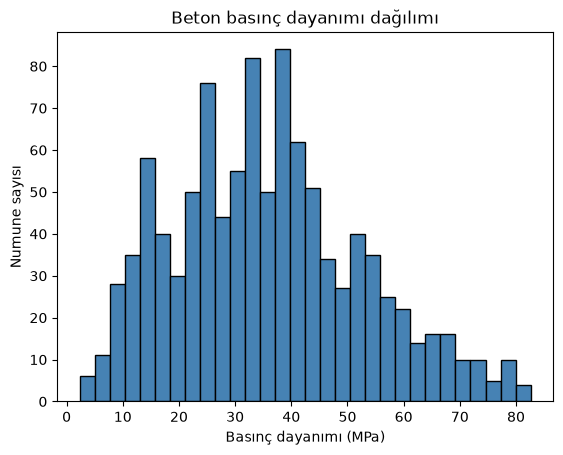

In [6]:
# 4. hedef değişkenin (strength) dağılımı
plt.figure()
plt.hist(df["strength"], bins=30, color="steelblue", edgecolor="black")
plt.xlabel("Basınç dayanımı (MPa)")
plt.ylabel("Numune sayısı")
plt.title("Beton basınç dayanımı dağılımı")
plt.savefig("grafikler/dayanim_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()

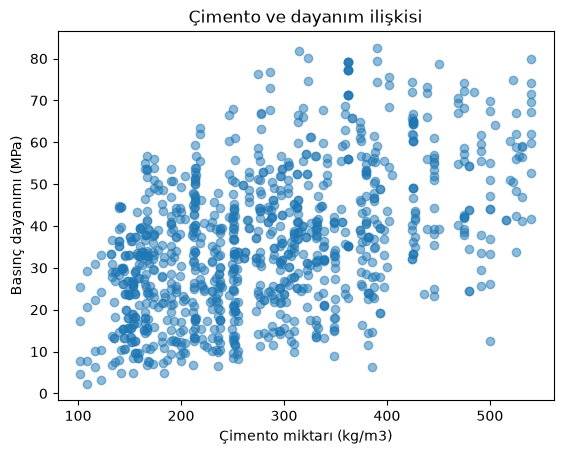

In [7]:
# çimento miktarı ile dayanım ilişkisi
plt.figure()
plt.scatter(df["cement"], df["strength"], alpha=0.5)
plt.xlabel("Çimento miktarı (kg/m3)")
plt.ylabel("Basınç dayanımı (MPa)")
plt.title("Çimento ve dayanım ilişkisi")
plt.savefig("grafikler/cimento_dayanim.png", dpi=150, bbox_inches="tight")
plt.show()

Beton yaşı sürekli değil, belli günlerde ölçülmüş (7, 28, 90 gün gibi). O yüzden scatter yerine yaş kırılımlı boxplot daha okunaklı.

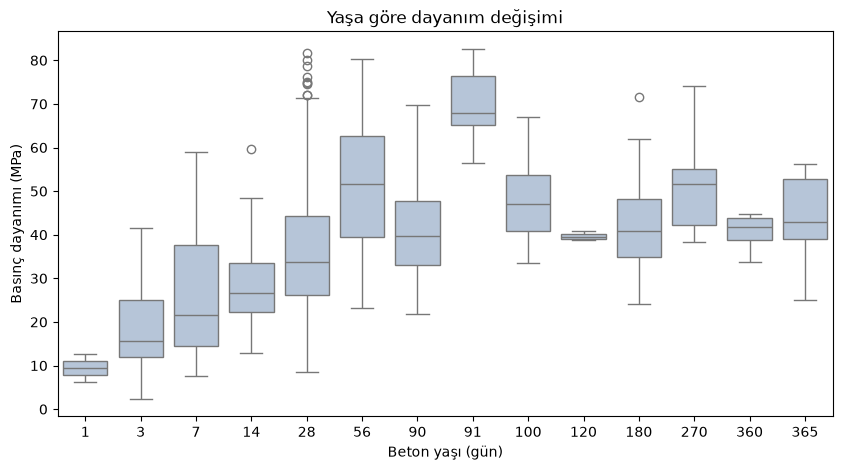

In [8]:
# beton yaşı ile dayanım ilişkisi
plt.figure(figsize=(10, 5))
sns.boxplot(x="age", y="strength", data=df, color="lightsteelblue")
plt.xlabel("Beton yaşı (gün)")
plt.ylabel("Basınç dayanımı (MPa)")
plt.title("Yaşa göre dayanım değişimi")
plt.savefig("grafikler/yas_dayanim.png", dpi=150, bbox_inches="tight")
plt.show()

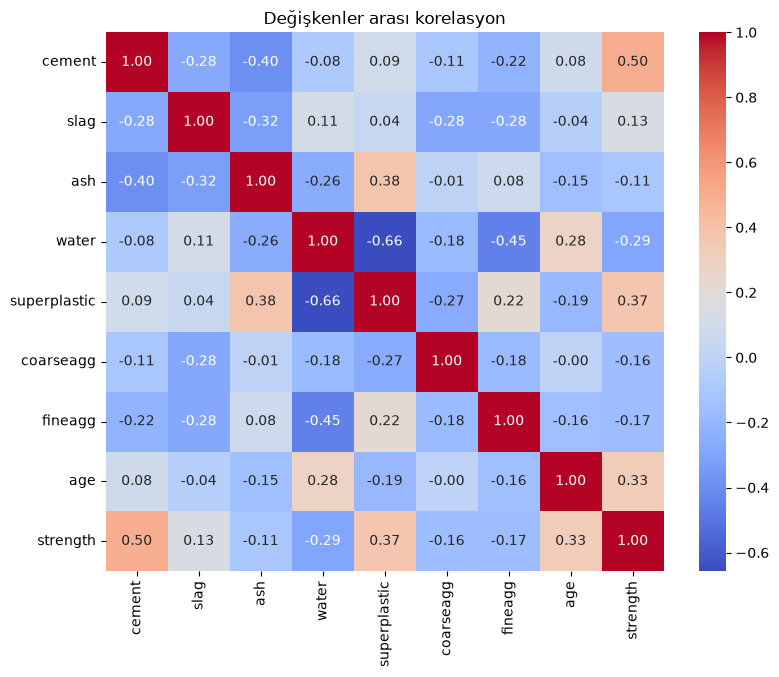

In [9]:
# korelasyon matrisi
plt.figure(figsize=(9, 7))
korelasyon = df.corr()
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Değişkenler arası korelasyon")
plt.savefig("grafikler/korelasyon_matrisi.png", dpi=150, bbox_inches="tight")
plt.show()

Korelasyon matrisinde çimento ile dayanım arasında pozitif, su ile dayanım arasında negatif ilişki görünüyor. Şantiyede su/çimento oranının neden bu kadar önemsendiğini veri de doğruluyor.

## Modelleme

Hocanın regresyon dersindeki akışı takip ediyorum: önce feature/target ayrımı, sonra train/test split, sonra üç model.

In [10]:
# 5. feature ve target değişkenlerin tanımlanması
X = df.drop("strength", axis=1)
y = df["strength"]
print(f"feature sayısı: {X.shape[1]}")

feature sayısı: 8


In [11]:
# 6. eğitim ve test veri setlerinin oluşturulması
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"eğitim seti: {X_train.shape[0]} örnek, test seti: {X_test.shape[0]} örnek")

eğitim seti: 824 örnek, test seti: 206 örnek


In [12]:
# 7. doğrusal, polinom ve random forest regresyon modellerinin oluşturulması
linear_model = LinearRegression()

polynomial_model = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear", LinearRegression())
    ]
)

random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 8. modelleri eğit (training) ve tahmin (prediction) yap
linear_model.fit(X_train, y_train)
polynomial_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
y_pred_polynomial = polynomial_model.predict(X_test)
y_pred_rf = random_forest_model.predict(X_test)

In [13]:
# 9. modellerin performansını karşılaştır
print(f"Doğrusal: mse: {mean_squared_error(y_test, y_pred_linear)}  --- R2: {r2_score(y_test, y_pred_linear)}")
print(f"Polynomial: mse: {mean_squared_error(y_test, y_pred_polynomial)}  --- R2: {r2_score(y_test, y_pred_polynomial)}")
print(f"Random Forest: mse: {mean_squared_error(y_test, y_pred_rf)}  --- R2: {r2_score(y_test, y_pred_rf)}")

Doğrusal: mse: 95.97094009110681  --- R2: 0.627553179231485
Polynomial: mse: 56.22756958783419  --- R2: 0.7817904095484642
Random Forest: mse: 29.85660710009169  --- R2: 0.884131609184953


In [14]:
# rmse değerleri (MPa cinsinden yorumlamak daha kolay)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
rmse_polynomial = np.sqrt(mean_squared_error(y_test, y_pred_polynomial))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Doğrusal rmse: {rmse_linear}")
print(f"Polynomial rmse: {rmse_polynomial}")
print(f"Random Forest rmse: {rmse_rf}")

Doğrusal rmse: 9.79647590162436
Polynomial rmse: 7.498504490085619
Random Forest rmse: 5.464119974899132


Polinomda degree=2 kullandım ama merak ettim, dereceyi artırınca ne oluyor? Deneyelim.

In [15]:
# deneme: polinom derecesini artırınca ne oluyor (overfitting kontrolü)
for derece in [2, 3, 4, 5]:
    deneme_model = Pipeline(
        [
            ("poly", PolynomialFeatures(degree=derece, include_bias=False)),
            ("linear", LinearRegression())
        ]
    )
    deneme_model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, deneme_model.predict(X_train))
    test_r2 = r2_score(y_test, deneme_model.predict(X_test))
    print(f"degree={derece}  train R2: {train_r2}  --- test R2: {test_r2}")

degree=2  train R2: 0.8074083482350378  --- test R2: 0.7817904095484642
degree=3  train R2: 0.917720828500071  --- test R2: 0.7941346300949605


degree=4  train R2: 0.9572962594133656  --- test R2: 0.8429169949568681


degree=5  train R2: 0.962933421181679  --- test R2: 0.7715531681394492


İtiraf edeyim, degree 3'te test skorunun düşmesini bekliyordum, düşmedi. Ama train R2 ile test R2 arasındaki fark her derecede açılıyor ve degree 5'te test skoru degree 2'nin bile altına indi. Model ezberledikçe genelleme bozuluyor. Karşılaştırmada degree=2 ile devam ediyorum, zaten random forest hepsinden iyi.

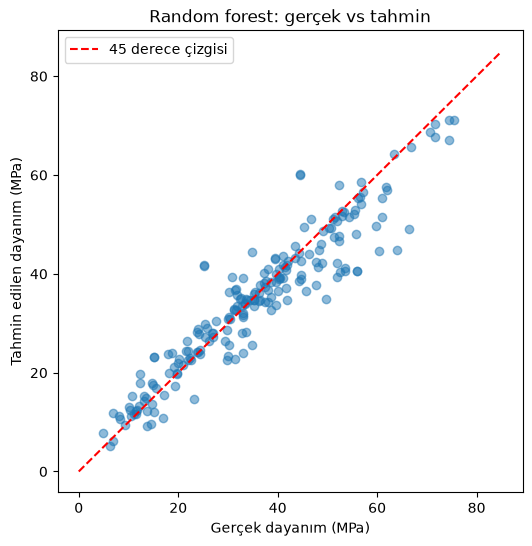

In [16]:
# 10. en iyi model (random forest) için gerçek vs tahmin grafiği
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([0, 85], [0, 85], color="red", linestyle="--", label="45 derece çizgisi")
plt.xlabel("Gerçek dayanım (MPa)")
plt.ylabel("Tahmin edilen dayanım (MPa)")
plt.title("Random forest: gerçek vs tahmin")
plt.legend()
plt.savefig("grafikler/gercek_vs_tahmin.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# 11. random forest feature importance incelenmesi
feature_importances = random_forest_model.feature_importances_
feature_names = X.columns

# önem derecelerini büyükten küçüğe sırala
feature_importances_sorted = sorted(zip(feature_importances, feature_names), reverse=True)

for importance, feature_name in feature_importances_sorted:
    print(f"{feature_name}: {importance}")

age: 0.33379905117419173
cement: 0.32486949508886404
water: 0.12640345585926568
slag: 0.07702463644029214
superplastic: 0.056178873149283715
fineagg: 0.03543744955661995
coarseagg: 0.028197651639351045
ash: 0.01808938709213151


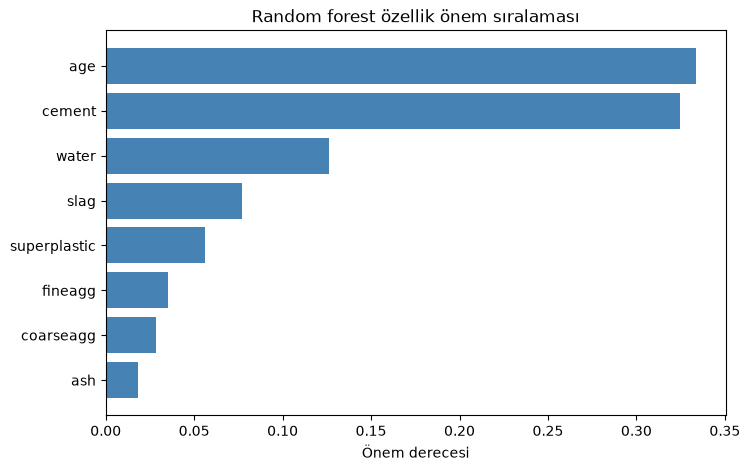

In [18]:
# feature importance bar grafiği
onem_degerleri = [imp for imp, isim in feature_importances_sorted]
ozellik_isimleri = [isim for imp, isim in feature_importances_sorted]

plt.figure(figsize=(8, 5))
plt.barh(ozellik_isimleri[::-1], onem_degerleri[::-1], color="steelblue")
plt.xlabel("Önem derecesi")
plt.title("Random forest özellik önem sıralaması")
plt.savefig("grafikler/ozellik_onemleri.png", dpi=150, bbox_inches="tight")
plt.show()

## Öznitelik mühendisliği: su/çimento oranı

Hoca öznitelik mühendisliği konusunda bazen en iyi özelliğin veride hazır durmadığını, onu bizim türetmemiz gerektiğini söylemişti. Benim aklıma ilk gelen su/çimento oranı oldu. Şantiyede beton kalitesini tek sayıyla konuşacaksak o sayı budur (Abrams kuralı). Veride water ve cement ayrı ayrı var ama oranları yok, bir satırla ekliyorum.

In [19]:
# 12. öznitelik mühendisliği: su/çimento oranının eklenmesi
df["su_cimento"] = df["water"] / df["cement"]

# yeni özelliğin ve ham bileşenlerin dayanımla korelasyonu
print(f"su_cimento - strength korelasyonu: {df['su_cimento'].corr(df['strength'])}")
print(f"water - strength korelasyonu: {df['water'].corr(df['strength'])}")
print(f"cement - strength korelasyonu: {df['cement'].corr(df['strength'])}")

su_cimento - strength korelasyonu: -0.5006920163176751
water - strength korelasyonu: -0.28963338498530444
cement - strength korelasyonu: 0.4978319193241573


Su tek başına -0.29 korelasyon veriyordu, oran -0.50. Yani türettiğimiz sütun ham sudan çok daha güçlü bir sinyal taşıyor. Şimdi aynı bölünmeyle (random_state=42) doğrusal regresyonu ve random forest'ı yeni sütunla yeniden eğitip eski skorlarla karşılaştırıyorum.

In [20]:
# 13. yeni özellik ile feature/target ayrımı ve aynı bölünmeyle split
X_fe = df.drop("strength", axis=1)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y, test_size=0.2, random_state=42)
print(f"yeni feature sayısı: {X_fe.shape[1]}")

yeni feature sayısı: 9


In [21]:
# doğrusal regresyon ve random forest'ı yeni özellikle yeniden eğit
linear_model_fe = LinearRegression()
random_forest_fe = RandomForestRegressor(n_estimators=100, random_state=42)

linear_model_fe.fit(X_train_fe, y_train_fe)
random_forest_fe.fit(X_train_fe, y_train_fe)

y_pred_linear_fe = linear_model_fe.predict(X_test_fe)
y_pred_rf_fe = random_forest_fe.predict(X_test_fe)

print(f"Doğrusal (8 özellik): R2: {r2_score(y_test, y_pred_linear)}")
print(f"Doğrusal (+su_cimento): R2: {r2_score(y_test_fe, y_pred_linear_fe)}")
print(f"Random Forest (8 özellik): R2: {r2_score(y_test, y_pred_rf)}")
print(f"Random Forest (+su_cimento): R2: {r2_score(y_test_fe, y_pred_rf_fe)}")

Doğrusal (8 özellik): R2: 0.627553179231485
Doğrusal (+su_cimento): R2: 0.6326431206688323
Random Forest (8 özellik): R2: 0.884131609184953
Random Forest (+su_cimento): R2: 0.8906354934364594


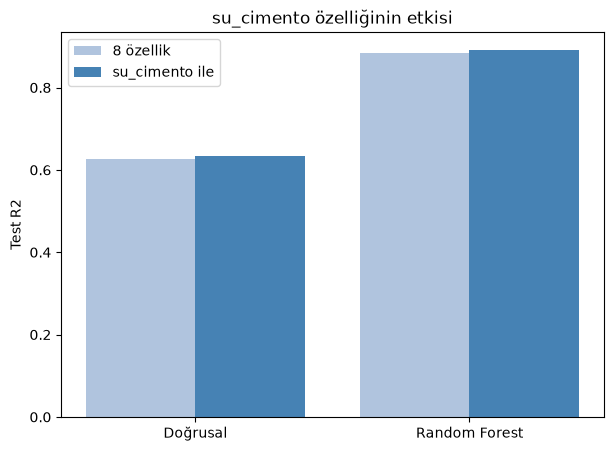

In [22]:
# öznitelik öncesi/sonrası karşılaştırma grafiği
modeller = ["Doğrusal", "Random Forest"]
r2_once = [r2_score(y_test, y_pred_linear), r2_score(y_test, y_pred_rf)]
r2_sonra = [r2_score(y_test_fe, y_pred_linear_fe), r2_score(y_test_fe, y_pred_rf_fe)]

x_konum = np.arange(len(modeller))
plt.figure(figsize=(7, 5))
plt.bar(x_konum - 0.2, r2_once, width=0.4, label="8 özellik", color="lightsteelblue")
plt.bar(x_konum + 0.2, r2_sonra, width=0.4, label="su_cimento ile", color="steelblue")
plt.xticks(x_konum, modeller)
plt.ylabel("Test R2")
plt.title("su_cimento özelliğinin etkisi")
plt.legend()
plt.savefig("grafikler/fe_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()

Doğrusal modelde beklediğim sıçrama olmadı, 0.628'den 0.633'e küçük bir kıpırdanma. Water ve cement zaten modelin içindeydi, oran onların taşıdığı bilginin bir kısmını tekrar ediyor. Random forest ise 0.884'ten 0.891'e çıktı. Küçük ama bedava bir kazanç, tek satır kod. Bu sütunun asıl hakkını aşağıda SHAP bölümünde göreceğiz.

## Lasso ve Ridge

Hocanın regresyon dersinde doğrusal ve polinomun yanında Lasso ve Ridge de vardı, ben ilk turda es geçmiştim. İkisi de katsayıları cezalandırıyor; Lasso gereksiz gördüğü katsayıyı tamamen sıfırlayabiliyor. Ceza katsayıların büyüklüğü üzerinden işlediği için ölçek önemli, o yüzden StandardScaler'lı pipeline kuruyorum.

In [23]:
# 14. lasso ve ridge regresyon modellerinin oluşturulması
lasso_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.1))
    ]
)

ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=0.1))
    ]
)

lasso_model.fit(X_train_fe, y_train_fe)
ridge_model.fit(X_train_fe, y_train_fe)

y_pred_lasso = lasso_model.predict(X_test_fe)
y_pred_ridge = ridge_model.predict(X_test_fe)

print(f"Lasso: mse: {mean_squared_error(y_test_fe, y_pred_lasso)}  --- R2: {r2_score(y_test_fe, y_pred_lasso)}")
print(f"Ridge: mse: {mean_squared_error(y_test_fe, y_pred_ridge)}  --- R2: {r2_score(y_test_fe, y_pred_ridge)}")

Lasso: mse: 95.15743205137355  --- R2: 0.6307102649366021
Ridge: mse: 94.65663132488955  --- R2: 0.6326537869885946


In [24]:
# 15. lasso katsayılarının incelenmesi (feature selection)
ozellik_isimleri = X_fe.columns
lasso_katsayilari = lasso_model.named_steps["lasso"].coef_

for isim, katsayi in zip(ozellik_isimleri, lasso_katsayilari):
    print(f"{isim}: {katsayi}")

cement: 9.075844021790125
slag: 7.6739089535915745
ash: 3.5328228421654035
water: -3.591770542947741
superplastic: 1.8258951533045538
coarseagg: -0.0
fineagg: 0.20754004239552537
age: 6.754773057460624
su_cimento: -2.0981955637489156


In [25]:
# alpha'yı büyütünce lasso daha çok katsayıyı sıfırlıyor
lasso_buyuk = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=1.0))])
lasso_buyuk.fit(X_train_fe, y_train_fe)

for isim, katsayi in zip(ozellik_isimleri, lasso_buyuk.named_steps["lasso"].coef_):
    print(f"{isim}: {katsayi}")
print(f"alpha=1.0 test R2: {r2_score(y_test_fe, lasso_buyuk.predict(X_test_fe))}")

cement: 5.785249997884944
slag: 4.3964919433423395
ash: 0.0
water: -2.254383300245052
superplastic: 3.300143276936442
coarseagg: -0.0
fineagg: -0.0
age: 5.335470189259989
su_cimento: -2.18295591081713
alpha=1.0 test R2: 0.5668863735473042


Skor tarafında sürpriz yok, ikisi de düz doğrusal regresyonla aynı seviyede kaldı çünkü model hala doğrusal. Asıl ilginç kısım katsayılar: Lasso alpha=0.1'de coarseagg'ın katsayısını sıfırladı, yani iri agrega miktarını modelden atmayı kendisi seçti. Alpha'yı 1.0'a çıkarınca ash ve fineagg de sıfırlandı ama test R2 0.57'ye düştü. Ceza arttıkça model sadeleşiyor ama performanstan yiyor. Lasso'nun bu davranışı bir çeşit otomatik özellik seçimi; yükü taşıyan değişkenlerin cement, slag, age ve water olduğunu söylüyor.

## K-fold çapraz doğrulama

Buraya kadar bütün skorlar tek bir train/test bölünmesinden geldi. O bölünme şanslı ya da şanssız olabilir. Hoca çapraz doğrulama dersinde stratified k-fold da göstermişti ama o, sınıflandırmada her fold'un sınıf oranlarını koruması için. Burada sınıf yok, dayanım sürekli bir değer; o yüzden düz KFold kullanıyorum.

In [26]:
# 16. k-fold çapraz doğrulama ile ana modellerin değerlendirilmesi
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

linear_cv = cross_val_score(LinearRegression(), X_fe, y, cv=kfold, scoring="r2")
polynomial_cv = cross_val_score(
    Pipeline(
        [
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("linear", LinearRegression())
        ]
    ),
    X_fe, y, cv=kfold, scoring="r2"
)
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X_fe, y, cv=kfold, scoring="r2")

print(f"Doğrusal fold skorları: {linear_cv}")
print(f"Doğrusal: ortalama R2: {np.mean(linear_cv)}  --- std: {np.std(linear_cv)}")
print(f"Polynomial: ortalama R2: {np.mean(polynomial_cv)}  --- std: {np.std(polynomial_cv)}")
print(f"Random Forest fold skorları: {rf_cv}")
print(f"Random Forest: ortalama R2: {np.mean(rf_cv)}  --- std: {np.std(rf_cv)}")

Doğrusal fold skorları: [0.63264312 0.59287439 0.56178853 0.6814709  0.54865733]
Doğrusal: ortalama R2: 0.6034868541679475  --- std: 0.048557701126984223
Polynomial: ortalama R2: 0.7838406215196532  --- std: 0.02504206277598149
Random Forest fold skorları: [0.88372357 0.91132735 0.89572438 0.90885611 0.9267176 ]
Random Forest: ortalama R2: 0.9052698002444369  --- std: 0.01459396528585783


## Aynı karışım birden fazla satırda mı?

Yaş sütunu 1, 3, 7, 28, 90, 365 gibi değerler alıyor. Şantiyede bir dökümden alınan numunelerin bir kısmı 7 günde, bir kısmı 28 günde kırılır. Aynı karışımın birden fazla satırı varsa rastgele KFold sızdırır: karışımın bir yaşı eğitime, başka bir yaşı teste düşer. Kontrol edelim.

In [27]:
# 16b. aynı karışımın kaç satırı var? sızıntı kontrolü
from sklearn.model_selection import GroupKFold

karisim = [c for c in df.columns if c not in ("age", "strength", "su_cimento")]
grup = df.groupby(karisim, sort=False).ngroup()
tekrar = df.groupby(karisim, sort=False).size()

print(f"{grup.nunique()} benzersiz karışım / {len(df)} satır")
print(f"{(tekrar > 1).sum()} karışım birden fazla yaşta ölçülmüş, {tekrar[tekrar > 1].sum()} satır")
print(f"en çok tekrar eden karışım: {tekrar.max()} satır")
print()

rf = RandomForestRegressor(n_estimators=100, random_state=42)
for ad, cv, gr in [("KFold     ", kfold, None),
                   ("GroupKFold", GroupKFold(n_splits=5), grup)]:
    r2 = cross_val_score(rf, X_fe, y, cv=cv, groups=gr, scoring="r2")
    rmse = -cross_val_score(rf, X_fe, y, cv=cv, groups=gr,
                            scoring="neg_root_mean_squared_error")
    print(f"{ad} ortalama R2: {r2.mean():.4f}   rmse: {rmse.mean():.2f}")

427 benzersiz karışım / 1030 satır
181 karışım birden fazla yaşta ölçülmüş, 784 satır
en çok tekrar eden karışım: 20 satır

KFold      ortalama R2: 0.9053   rmse: 5.12
GroupKFold ortalama R2: 0.8903   rmse: 5.50


1030 satır aslında 427 karışım. GroupKFold ile R2 0.9053'ten 0.8903'e, rmse 5.12'den 5.50 MPa'ya geliyor. Dürüst rakam bu. Aşağıdaki bölümlerde model karşılaştırması için tek bölünme skorlarını kullanmaya devam ediyorum.

Doğrusal modelin cv ortalaması 0.60, tek bölünmedeki 0.63'ün altında. Demek ki benim test setim doğrusal model için biraz şanslı bir bölünmeymiş. Random forest beş fold'da 0.88 ile 0.93 arasında gezip ortalama 0.91'e oturdu, standart sapması da küçük. Tek sayı yerine ortalama ve sapmayı birlikte görmek daha güven veriyor.

## Randomized search ile hiperparametre ayarlama

İlk sürümü bitirirken aklımda kalan soru şuydu: n_estimators ve max_depth ile oynayınca 0.88'in üstüne çıkabilir miyim? Grid search her kombinasyonu tek tek dener; benim aralıklarla bu 108 kombinasyon x 5 fold demek. RandomizedSearchCV bunların içinden rastgele 10 tanesini deniyor, büyük arama uzaylarında mantıklısı bu.

In [28]:
# 17. randomized search ile random forest hiperparametre ayarlama
param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_fe, y_train_fe)

y_pred_search = random_search.best_estimator_.predict(X_test_fe)

sonuc_df = pd.DataFrame([{
    "model": "Random Forest",
    "yontem": "random_search",
    "cv en iyi score": round(random_search.best_score_, 4),
    "test score": round(r2_score(y_test_fe, y_pred_search), 4),
    "en iyi parametre seti": str(random_search.best_params_)
}])
print(sonuc_df)
print(f"en iyi modelin test rmse değeri: {np.sqrt(mean_squared_error(y_test_fe, y_pred_search))}")

           model         yontem  cv en iyi score  test score  \
0  Random Forest  random_search           0.9109      0.8931   

                               en iyi parametre seti  
0  {'n_estimators': 300, 'min_samples_split': 2, ...  
en iyi modelin test rmse değeri: 5.249329221701054


Cevap: çıkabiliyorum ama az. En iyi ayarlar (n_estimators=300, max_features=0.5, max_depth=None) test R2'yi 0.891'den 0.893'e getirdi. Saatlerce parametre kurcalamak yerine tek satırda eklediğim su_cimento sütununun daha çok kazandırmış olması bana ders oldu: önce veriyi tanı, sonra ayar çek.

## SHAP ile modelin kararlarına bakmak

Feature importance hangi değişkenin önemli olduğunu söylüyor ama hangi yönde ittiğini söylemiyor. Hocanın açıklanabilirlik dersindeki SHAP tam bunu yapıyor: her tahmin için her değişkenin katkısını yönüyle beraber çıkarıyor. Test setim 206 örnek olduğu için hepsini kullandım, hesap makul sürede bitti.

In [29]:
# 18. shap ile özellik katkılarının incelenmesi
en_iyi_rf = random_search.best_estimator_

shap_explainer = shap.TreeExplainer(en_iyi_rf)
shap_values = shap_explainer.shap_values(X_test_fe)

# regresyonda sınıf dallanması yok, shap_values direkt (örnek, özellik) boyutlu geliyor
print(f"shap_values boyutu: {shap_values.shape}")

shap_values boyutu: (206, 9)


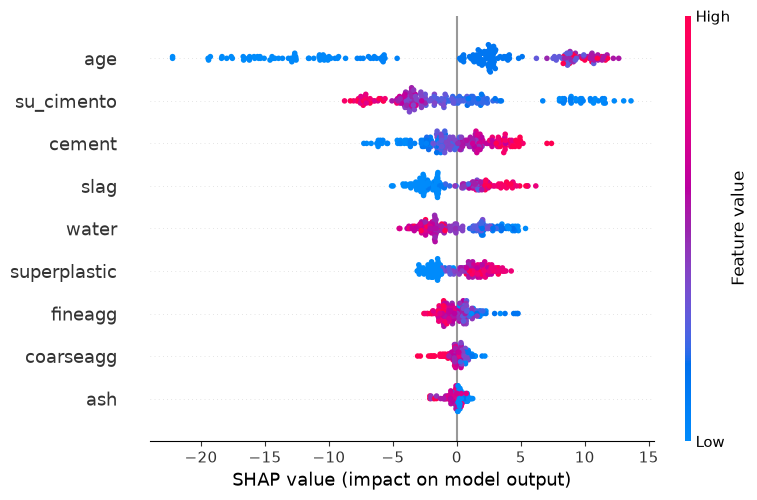

In [30]:
# shap özet grafiği
shap.summary_plot(shap_values, X_test_fe, show=False)
plt.savefig("grafikler/shap_ozeti.png", dpi=150, bbox_inches="tight")
plt.show()

Grafikte her nokta bir test örneği. age satırında kırmızı noktalar (yüksek yaş) sağda: beton yaşlandıkça tahmin yukarı itiliyor. su_cimento tam tersi, kırmızı noktalar solda: oran yükseldikçe dayanım tahmini düşüyor. Mikserin başındaki "su katma" tartışmasının modeldeki karşılığı bu. Benim eklediğim su_cimento sütununun age'den sonra ikinci en etkili değişken çıkması da ayrıca hoş, alan bilgisi modele buradan girmiş.

## Çıkarımlar

- Beton davranışı doğrusal değil, doğrusal regresyonun geride kalması bunu doğruluyor. Polinom özellikler ve random forest belirgin şekilde daha iyi.
- Tek satırlık alan bilgisi (su_cimento) random forest'ı 0.884'ten 0.891'e taşıdı; randomized search üstüne ancak 0.893'ü ekledi. Reçete bilgisi parametre ayarından çok kazandırdı.
- K-fold, tek bölünmeden daha güvenilir bir tablo verdi: random forest ortalama R2 0.91, std 0.01. Regresyonda sınıf olmadığı için stratified değil düz KFold kullanıldı.
- Lasso coarseagg'ı sıfırlayarak kendi özellik seçimini yaptı; Ridge katsayıları küçültüyor ama sıfırlamıyor.
- SHAP'ta en etkili iki değişken age ve su_cimento; yönler saha tecrübesiyle uyumlu (yaş arttıkça dayanım artar, su/çimento arttıkça düşer).
- Model karışım reçetesi denerken ön kontrol için işe yarar, 28 günlük kür sonucunu beklemeden kabaca bir fikir verir. Ama numune testinin yerini tutmaz; şartnameler gerçek basınç deneyi ister, model sadece yol gösterici.